# LoRA Feasibility

> The goal of this notebook is to:
> 1. Test the feasibility of creating an image generation model by using a combination of `diffusion` and `LoRA (low rank adapter)`.
> 2. Process the images in the dataset to make it optimal for model ingestion.
> 3. Perform any additional EDA necessary to determine the best way to preprocess and/or trasnform the images in the dataset. 

## Imports and setup

In [23]:
import os
import pandas as pd
from PIL import Image
import torch

print("GPU available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print(torch.cuda.get_device_name(0))

GPU available: True
NVIDIA GeForce RTX 3050 6GB Laptop GPU


Build caption manifest
> *manifest = index file containing which the training script reads

In [24]:
attrs = pd.read_csv("../data/npc_attributes.csv")
npc = pd.read_csv("../data/npc.csv")[["id", "Location"]]
manifest = attrs.merge(npc, on="id", how="left")

def finalize_caption(row):
    base = row["caption"] if pd.notna(row["caption"]) else "an OSRS character"
    if pd.notna(row["Location"]):
        base += f", found in {row['Location']}"
    return base

manifest["final_caption"] = manifest.apply(finalize_caption, axis=1)
manifest[["id", "final_caption"]].sample(5)

,id,final_caption
3672,3672,"Skulgrimen: Human, male, a beard, brown hair, ..."
496,496,"Boulder: Troll, male, a goatee, a mask, glasse..."
3553,3553,"Shipwright Steve: Human, male, a beard, a helm..."
1365,1365,"Feral Vampyre: Vampyre, found in Morytania"
3118,3118,"Praistan Ebola: Gnome, male, a beard, a hood, ..."


Filter to images that exist and split by type

In [25]:
chathead_ids = {int(f.split(".")[0]) for f in os.listdir("../data/chatheads")}
body_ids = {int(f.split(".")[0]) for f in os.listdir("../data/bodies")}

chathead_manifest = manifest[manifest["id"].isin(chathead_ids)].copy()
chathead_manifest["image_path"] = chathead_manifest["id"].apply(lambda i: f"../data/chatheads/{i}.png")

body_manifest = manifest[manifest["id"].isin(body_ids)].copy()
body_manifest["image_path"] = body_manifest["id"].apply(lambda i: f"../data/bodies/{i}.png")

print(len(chathead_manifest), len(body_manifest))

3473 4301


Save chathead manifest to disk (so the code runs faster)

In [26]:
chathead_manifest[["image_path", "final_caption"]].to_csv(
    "../data/chathead_lora_manifest.csv", index=False
)
print(len(chathead_manifest), "rows saved")

3473 rows saved


## EDA on Images in Chatheads and Bodies

Perform some EDA on image sizes (separate the analysis for chatheads vs bodies) to understand how much the spread is for images that need to be preprocessed

In [27]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def get_dims(folder):
    dims = []
    for f in os.listdir(f"../data/{folder}"):
        with Image.open(f"../data/{folder}/{f}") as im:
            dims.append(im.size)
    df = pd.DataFrame(dims, columns=["width", "height"])
    df["aspect_ratio"] = df["width"] / df["height"]
    return df

C:\Users\camiz\AppData\Local\Temp\ipykernel_25072\3860225644.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1,1].boxplot([chathead_dims["width"], chathead_dims["height"], chathead_dims["aspect_ratio"]],


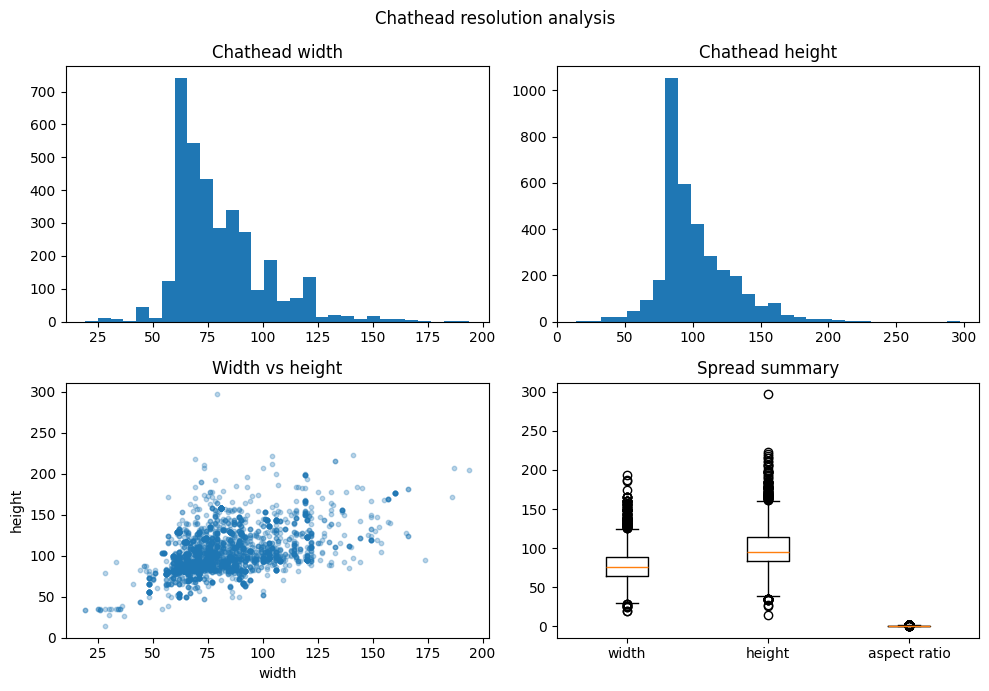

             width       height  aspect_ratio
count  3473.000000  3473.000000   3473.000000
mean     80.179672   100.936654      0.817713
std      20.579311    26.041763      0.197003
min      19.000000    14.000000      0.265993
25%      65.000000    83.000000      0.707071
50%      76.000000    95.000000      0.777174
75%      89.000000   114.000000      0.906780
max     194.000000   297.000000      2.000000


In [28]:
# Chatheads
chathead_dims = get_dims("chatheads")

fig, axes = plt.subplots(2, 2, figsize=(10, 7))
axes[0,0].hist(chathead_dims["width"], bins=30); axes[0,0].set_title("Chathead width")
axes[0,1].hist(chathead_dims["height"], bins=30); axes[0,1].set_title("Chathead height")
axes[1,0].scatter(chathead_dims["width"], chathead_dims["height"], alpha=0.3, s=10)
axes[1,0].set_title("Width vs height"); axes[1,0].set_xlabel("width"); axes[1,0].set_ylabel("height")
axes[1,1].boxplot([chathead_dims["width"], chathead_dims["height"], chathead_dims["aspect_ratio"]],
                   labels=["width", "height", "aspect ratio"])
axes[1,1].set_title("Spread summary")
plt.suptitle("Chathead resolution analysis")
plt.tight_layout()
plt.savefig("../img/chathead_resolution_eda.png")
plt.show()

print(chathead_dims.describe())

> `Chathead` images are easier to preprocess first since most images tend to be the same size. It should be fairly easy to resize and pad without compromising information loss.

C:\Users\camiz\AppData\Local\Temp\ipykernel_25072\3266381031.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1,1].boxplot([body_dims["width"], body_dims["height"], body_dims["aspect_ratio"]],


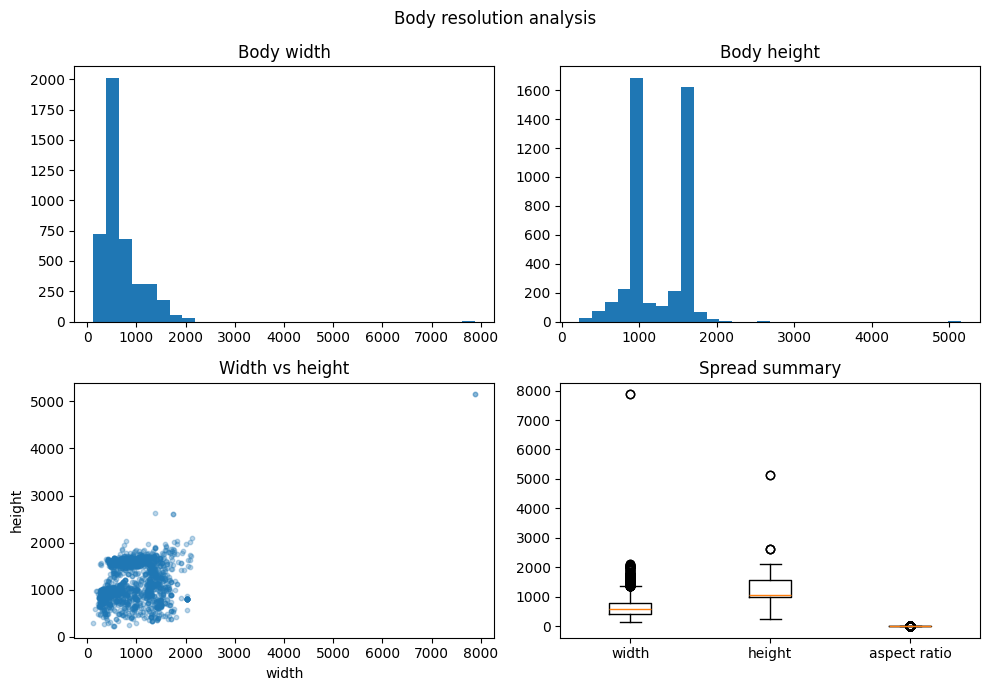

             width       height  aspect_ratio
count  4301.000000  4301.000000   4301.000000
mean    687.372704  1233.700070      0.608927
std     390.185444   361.397392      0.473975
min     128.000000   230.000000      0.173213
25%     420.000000   973.000000      0.376663
50%     575.000000  1058.000000      0.431959
75%     796.000000  1578.000000      0.605216
max    7880.000000  5150.000000      4.355499


In [29]:
# Bodies
body_dims = get_dims("bodies")

fig, axes = plt.subplots(2, 2, figsize=(10, 7))
axes[0,0].hist(body_dims["width"], bins=30); axes[0,0].set_title("Body width")
axes[0,1].hist(body_dims["height"], bins=30); axes[0,1].set_title("Body height")
axes[1,0].scatter(body_dims["width"], body_dims["height"], alpha=0.3, s=10)
axes[1,0].set_title("Width vs height"); axes[1,0].set_xlabel("width"); axes[1,0].set_ylabel("height")
axes[1,1].boxplot([body_dims["width"], body_dims["height"], body_dims["aspect_ratio"]],
                   labels=["width", "height", "aspect ratio"])
axes[1,1].set_title("Spread summary")
plt.suptitle("Body resolution analysis")
plt.tight_layout()
plt.savefig("../img/body_resolution_eda.png")
plt.show()

print(body_dims.describe())

> Images in the `bodies` dataset are more spread out. Might be worth looking into the images that are outliers and see what the risks are if we preprocess these--but let's table this after testing the chatheads feasibility into the model.

Dropped 2 outlier(s)


C:\Users\camiz\AppData\Local\Temp\ipykernel_25072\1700100249.py:10: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1,1].boxplot([body_dims_filtered["width"], body_dims_filtered["height"], body_dims_filtered["aspect_ratio"]],


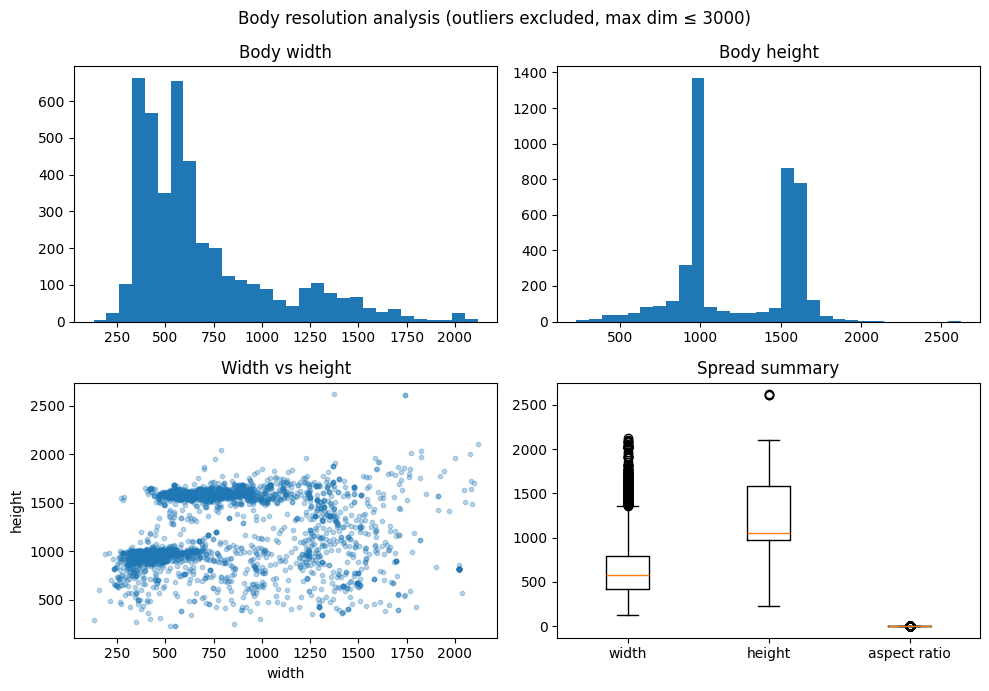

             width       height  aspect_ratio
count  4299.000000  4299.000000   4299.000000
mean    684.026518  1231.878111      0.608499
std     358.093361   351.466263      0.473669
min     128.000000   230.000000      0.173213
25%     420.000000   973.000000      0.376603
50%     575.000000  1055.000000      0.431934
75%     796.000000  1578.000000      0.604784
max    2120.000000  2620.000000      4.355499


In [30]:
# Bodies, excluding extreme outliers (max dimension > 3000)
body_dims_filtered = body_dims[(body_dims["width"] <= 3000) & (body_dims["height"] <= 3000)]
print(f"Dropped {len(body_dims) - len(body_dims_filtered)} outlier(s)")

fig, axes = plt.subplots(2, 2, figsize=(10, 7))
axes[0,0].hist(body_dims_filtered["width"], bins=30); axes[0,0].set_title("Body width")
axes[0,1].hist(body_dims_filtered["height"], bins=30); axes[0,1].set_title("Body height")
axes[1,0].scatter(body_dims_filtered["width"], body_dims_filtered["height"], alpha=0.3, s=10)
axes[1,0].set_title("Width vs height"); axes[1,0].set_xlabel("width"); axes[1,0].set_ylabel("height")
axes[1,1].boxplot([body_dims_filtered["width"], body_dims_filtered["height"], body_dims_filtered["aspect_ratio"]],
                   labels=["width", "height", "aspect ratio"])
axes[1,1].set_title("Spread summary")
plt.suptitle("Body resolution analysis (outliers excluded, max dim ≤ 3000)")
plt.tight_layout()
plt.savefig("../img/body_resolution_eda_filtered.png")
plt.show()

print(body_dims_filtered.describe())

> After removing the extreme outliers (width and/or height >3000), the spread of the image dimensions looks a bit more interesting. It looks like some image types tend to cluster around a certain height--might be worth investigating after doing the feasibility of the chathead image generation. 

## Additional EDA on Chathead Images
> Find out what the smallest and largest images in the dataset look like so we can understand what padding strategy to apply, so that we don't accidentally cut off important features like hats, horns, etc.

In [31]:
def get_dims_with_id(folder):
    records = []
    for f in os.listdir(f"../data/{folder}"):
        npc_id = int(f.split(".")[0])
        with Image.open(f"../data/{folder}/{f}") as im:
            w, h = im.size
        records.append({"id": npc_id, "width": w, "height": h, "max_dim": max(w, h)})
    return pd.DataFrame(records)

chathead_dims_id = get_dims_with_id("chatheads")

#### Largest chatheads analysis

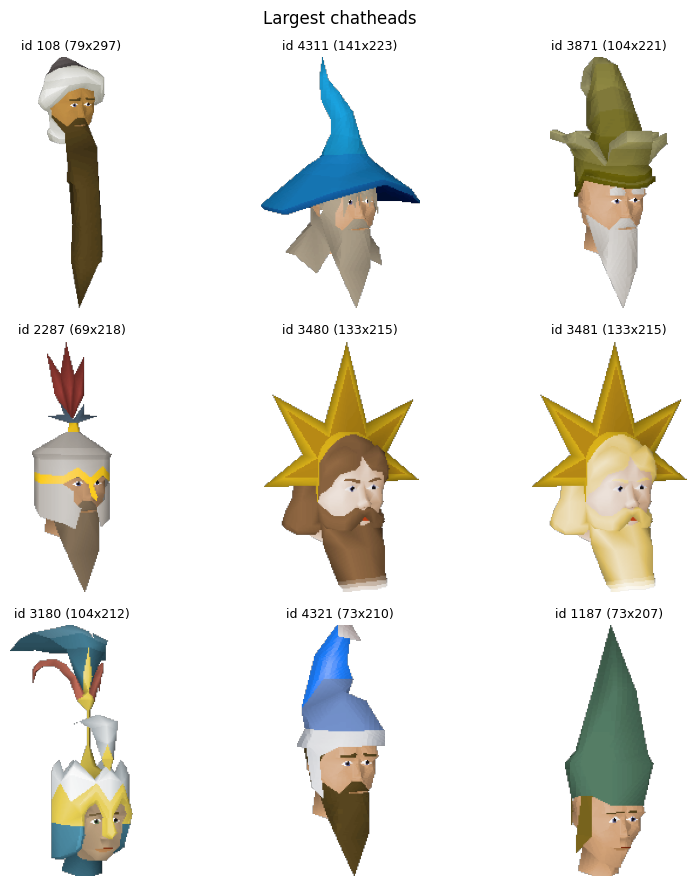

In [32]:
# Largest chatheads
n = 9 # number of largest chatheads to display
largest = chathead_dims_id.nlargest(n, "max_dim")

fig, axes = plt.subplots(3, 3, figsize=(9, 9))
for ax, (_, row) in zip(axes.flat, largest.iterrows()):
    img = Image.open(f"../data/chatheads/{row['id']}.png")
    ax.imshow(img)
    ax.set_title(f"id {row['id']} ({row['width']}x{row['height']})", fontsize=9)
    ax.axis("off")
plt.suptitle("Largest chatheads")
plt.tight_layout()
plt.show()

> Makes sense that most of the largest chatheads have some kind of appendage or accessory that adds to their height--this adds up to the chathead resolution analysis above where we see more spread in the height vs the width (most npcs have something on them that makes the image taller). It's interesting though that npcs like `id 3480` and `id 3481` have large hats and long beards but the beards seem to be intentionally cut off in the image. So it might be worth looking at the CLIP results of npcs like this to see if the beard feature was detected--and if so, then the image generation model should be able to learn from this via the CLIP embeddings.

In [33]:
# Check clip embeddings
import numpy as np
import pandas as pd

emb = np.load("../data/chathead_embeddings.npy")
ids = np.load("../data/chathead_embedding_ids.npy")

target_ids = [3480, 3481]

for npc_id in target_ids:
    idx = np.where(ids == npc_id)[0]
    if len(idx) == 0:
        print(f"id {npc_id}: no embedding found")
        continue
    vec = emb[idx[0]]
    print(f"id {npc_id}: embedding shape {vec.shape}, norm {np.linalg.norm(vec):.3f}")
    print(f"  first 10 dims: {vec[:10]}")

id 3480: embedding shape (512,), norm 1.000
  first 10 dims: [ 0.01607439  0.01869018  0.00405378  0.03508994 -0.0184101  -0.05914831
  0.02035888  0.02191377 -0.06378855 -0.0098124 ]
id 3481: embedding shape (512,), norm 1.000
  first 10 dims: [ 0.00834437  0.01840463 -0.02014336  0.02877697  0.00022399 -0.00401253
  0.01144627  0.03545893 -0.01061787  0.02585598]


In [34]:
# What actually matters: does the caption mention the beard?
attrs = pd.read_csv("../data/npc_attributes.csv")
attrs[attrs["id"].isin(target_ids)][
    ["id", "Name", "facial_hair", "facial_hair_conf", "caption"]
]

,id,Name,facial_hair,facial_hair_conf,caption
3480,3480,Seer,beard,0.807038,"Seer: Dwarf, a beard, brown hair, a crown"
3481,3481,Seer,clean_shaven,0.359600,"Seer: Dwarf, female, blonde hair, a crown"


> Summoning the CLIP embeddings for the specifc id's, it looks like CLIP was not able to detect `id 3481`'s beard--I'm guessing because the color of the beard is such a light shade that it almost blends in with the npc's skin tone (a low contrast case). Let's numerically verify how close `id 3481 `'s `hair_color` is to its `skin_tone`.

In [35]:
import numpy as np
from PIL import Image

img = Image.open("../data/chatheads/3481.png").convert("RGB")
arr = np.array(img)

# crop rough regions -- adjust coordinates after eyeballing the image dims
h, w, _ = arr.shape
hair_region = arr[0:int(h*0.25), :, :]        # top portion, likely hair
skin_region = arr[int(h*0.45):int(h*0.65), :, :]  # mid-face, likely skin

hair_avg = hair_region.reshape(-1, 3).mean(axis=0)
skin_avg = skin_region.reshape(-1, 3).mean(axis=0)

print(f"Hair avg RGB: {hair_avg}")
print(f"Skin avg RGB: {skin_avg}")

euclidean_dist = np.linalg.norm(hair_avg - skin_avg)
print(f"Euclidean distance in RGB space: {euclidean_dist:.2f}")

Hair avg RGB: [18.20669599 14.42417364  2.17137183]
Skin avg RGB: [144.97254765 127.68158769  84.02902605]
Euclidean distance in RGB space: 188.67


In [36]:
# then compare to the other target id (3480)
img2 = Image.open("../data/chatheads/3480.png").convert("RGB")
arr2 = np.array(img2)
h2, w2, _ = arr2.shape
hair_region2 = arr2[0:int(h2*0.25), :, :]
skin_region2 = arr2[int(h2*0.45):int(h2*0.65), :, :]
hair_avg2 = hair_region2.reshape(-1, 3).mean(axis=0)
skin_avg2 = skin_region2.reshape(-1, 3).mean(axis=0)
print(f"Hair avg RGB: {hair_avg2}")
print(f"Skin avg RGB: {skin_avg2}")
print(f"id 3480 - Euclidean distance: {np.linalg.norm(hair_avg2 - skin_avg2):.2f}")

Hair avg RGB: [18.20669599 14.42417364  2.17137183]
Skin avg RGB: [119.90050708  98.63734919  60.61566707]
id 3480 - Euclidean distance: 144.39


In [37]:
attrs = pd.read_csv("../data/npc_attributes.csv")
print(attrs[attrs["id"].isin([3480, 3481])][["id", "hair_color", "hair_color_conf"]])

# broader check: does low facial_hair_conf correlate with light hair colors?
low_conf = attrs[(attrs["facial_hair"] == "clean_shaven") & (attrs["facial_hair_conf"] < 0.4)]
print(low_conf["hair_color"].value_counts())

        id hair_color  hair_color_conf
3480  3480      brown         0.617482
3481  3481     blonde         0.507673
hair_color
bald         137
brown         34
unnatural     22
red           10
blonde         9
black          4
Name: count, dtype: int64


In [38]:
# total count per hair_color across the whole dataset
total_by_color = attrs["hair_color"].value_counts()

# low-conf clean_shaven count per hair_color (excluding bald, which isn't a "miss")
low_conf_by_color = low_conf[low_conf["hair_color"] != "bald"]["hair_color"].value_counts()

miss_rate = (low_conf_by_color / total_by_color).dropna().sort_values(ascending=False)
print(miss_rate)

hair_color
unnatural    0.131737
blonde       0.115385
black        0.097561
brown        0.084367
red          0.044643
Name: count, dtype: float64


> CLIP's facial-hair detection missed a beard on NPC 3481 while correctly catching a similar one on 3480, and a normalized miss-rate analysis across the dataset showed blonde hair has the second-highest miss rate (11.5%) behind only "unnatural" colors--well above brown (8.4%) or red (4.5%). This is directionally consistent with the hypothesis that light hair blending into skin tone reduces CLIP's detection accuracy, though the small sample size (9 blonde misses) means it should be framed as suggestive rather than conclusive. This suggests that we need to handle `attribute confidence` (aka caption/label quality) before feeding the images to the model--to handle this, let's use a `confidence score` to omit uncertain "claims" from the caption rather than asserting them as facts.

#### Smallest Chatheads Analysis

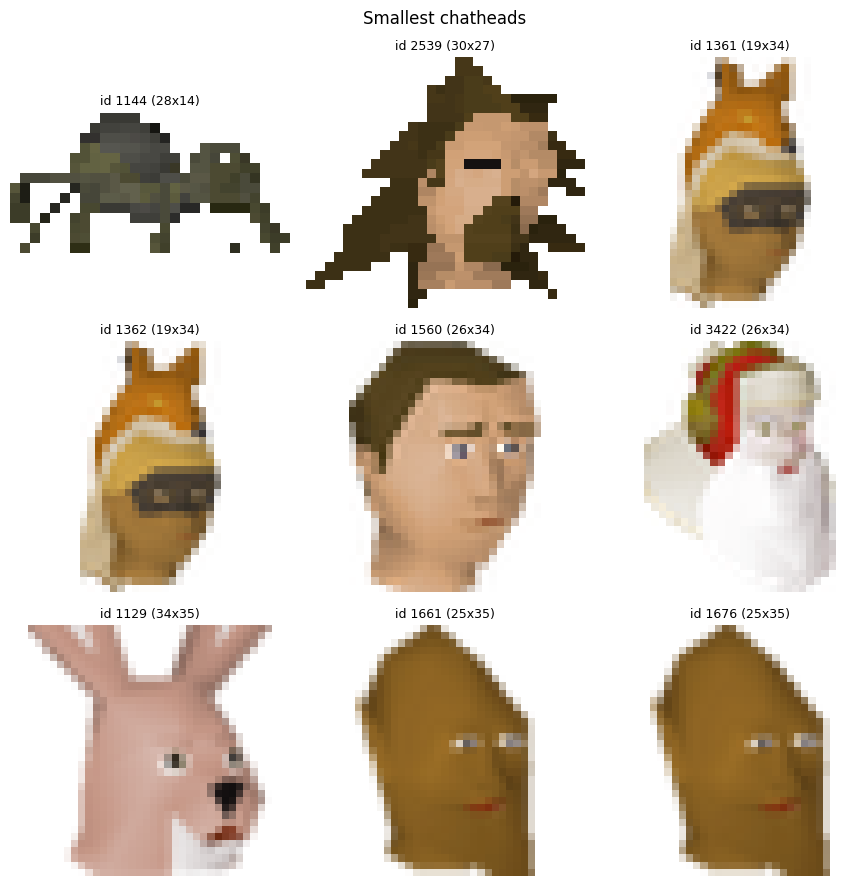

In [39]:
# Smallest chatheads
smallest = chathead_dims_id.nsmallest(n, "max_dim")

fig, axes = plt.subplots(3, 3, figsize=(9, 9))
for ax, (_, row) in zip(axes.flat, smallest.iterrows()):
    img = Image.open(f"../data/chatheads/{row['id']}.png")
    ax.imshow(img)
    ax.set_title(f"id {row['id']} ({row['width']}x{row['height']})", fontsize=9)
    ax.axis("off")
plt.suptitle("Smallest chatheads")
plt.tight_layout()
plt.show()

> Based on this sample of smallest chathead images, I wanted to investigate the following things:
> 1. Is `id 1129`'s ears really cut off? And if so, are there other chatheads like this that might risk skewing the LoRA and other image generation model components (i.e. cutting off the ears might risk the model not learning about npcs with ears, etc.)
> 2. Are there other npc chatheads that have near-duplicate appearances like `id 1161` and `id 1676` --> upon doing some digging, it looks like there are visually similar npcs--while they have distinct ids and different lores/roles based on the `npc.csv` file, having visually similar images in the dataset can be a visually redundant risk for training purposes.
>
> It's for this reason, we need to detect visual near-duplicates before doing the preprocessing that way we can save on compute and load the appropriate data for modelling purposes.

### Detecting visually similar chatheads

In [40]:
npc = pd.read_csv("../data/npc.csv")[["id", "Name", "Race", "Location"]]
npc = npc.rename(columns={"Race": "Class"})

Use a threshold of 98% similarity first and trim it down if we want less clusters to train on. Clustering by class makes sense but since I lack OSRS domain knowledge, I want to test if I can capture more clusters based purely on visual similarity.

In [41]:
import numpy as np
import pandas as pd

emb = np.load("../data/chathead_embeddings.npy")
ids = np.load("../data/chathead_embedding_ids.npy")

norm_emb = emb / np.linalg.norm(emb, axis=1, keepdims=True)
sim_matrix = norm_emb @ norm_emb.T

THRESHOLD = 0.98  # start high (near-identical); lower later if too few results
n = len(ids)
iu = np.triu_indices(n, k=1)
sims = sim_matrix[iu]
mask = sims >= THRESHOLD

dup_df = pd.DataFrame({
    "id_a": ids[iu[0][mask]],
    "id_b": ids[iu[1][mask]],
    "similarity": sims[mask]
}).sort_values("similarity", ascending=False)

print(f"{len(dup_df)} near-duplicate pairs found (threshold={THRESHOLD})")

# bring in names/captions for context (reuse npc loaded above -- already has Class renamed)
dup_df = dup_df.merge(npc, left_on="id_a", right_on="id", suffixes=("", "_a")).rename(columns={"Name":"Name_a","Class":"Class_a","Location":"Location_a"}).drop(columns="id")
dup_df = dup_df.merge(npc, left_on="id_b", right_on="id", suffixes=("", "_b")).rename(columns={"Name":"Name_b","Class":"Class_b","Location":"Location_b"}).drop(columns="id")

dup_df.to_csv("../data/chathead_near_duplicates.csv", index=False)
dup_df.head(20)

9390 near-duplicate pairs found (threshold=0.98)


,id_a,id_b,similarity,Name_a,Class_a,Location_a,Name_b,Class_b,Location_b
0,287,293,1.000001,Banker,Human,Bank,Banker,Werewolf,Canifis
1,287,298,1.000001,Banker,Human,Bank,Banker,Human,Draynor Village
2,287,317,1.000001,Banker,Human,Bank,Banker,Human,Tutorial Island
3,287,1520,1.000001,Banker,Human,Bank,Fry,Human,Rabbit Hole
4,298,1520,1.000001,Banker,Human,Draynor Village,Fry,Human,Rabbit Hole
5,298,317,1.000001,Banker,Human,Draynor Village,Banker,Human,Tutorial Island
6,293,298,1.000001,Banker,Werewolf,Canifis,Banker,Human,Draynor Village
7,293,1520,1.000001,Banker,Werewolf,Canifis,Fry,Human,Rabbit Hole
8,293,317,1.000001,Banker,Werewolf,Canifis,Banker,Human,Tutorial Island
9,317,1520,1.000001,Banker,Human,Tutorial Island,Fry,Human,Rabbit Hole


In [42]:
# Group into clusters of near-duplicates
import networkx as nx

G = nx.Graph()
G.add_edges_from(zip(dup_df["id_a"], dup_df["id_b"]))
clusters = list(nx.connected_components(G))
print(f"{len(clusters)} duplicate clusters found, sizes: {sorted([len(c) for c in clusters], reverse=True)[:10]}")

381 duplicate clusters found, sizes: [476, 176, 41, 33, 23, 23, 21, 21, 19, 19]


In [43]:
# Cluster based on embeddings using HDBSCAN
# we use hierarchical density-based clustering to find clusters of similar embeddings, which can help identify groups of similar NPCs.
from sklearn.cluster import HDBSCAN

emb = np.load("../data/chathead_embeddings.npy")
ids = np.load("../data/chathead_embedding_ids.npy")
norm_emb = emb / np.linalg.norm(emb, axis=1, keepdims=True)

clusterer = HDBSCAN(min_cluster_size=10, metric="euclidean")
cluster_labels = clusterer.fit_predict(norm_emb)

cluster_df = pd.DataFrame({"id": ids, "cluster": cluster_labels})
n_clusters = len(set(cluster_labels)) - (1 if -1 in cluster_labels else 0)
n_noise = (cluster_labels == -1).sum()
print(f"{n_clusters} clusters found, {n_noise} noise points (unclustered)")

39 clusters found, 2688 noise points (unclustered)


### Perform EDA on clusters identified

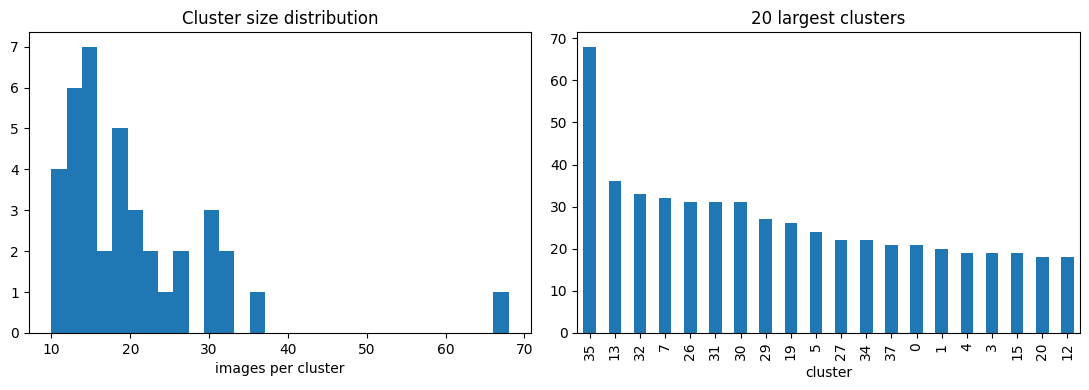

count    39.000000
mean     20.128205
std      10.694759
min      10.000000
25%      13.500000
50%      18.000000
75%      23.000000
max      68.000000
Name: count, dtype: float64


In [44]:
cluster_sizes = cluster_df[cluster_df["cluster"] != -1]["cluster"].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].hist(cluster_sizes, bins=30)
axes[0].set_title("Cluster size distribution")
axes[0].set_xlabel("images per cluster")

cluster_sizes.head(20).plot(kind="bar", ax=axes[1])
axes[1].set_title("20 largest clusters")
plt.tight_layout()
plt.savefig("../img/chathead_cluster_sizes.png")
plt.show()

print(cluster_sizes.describe())

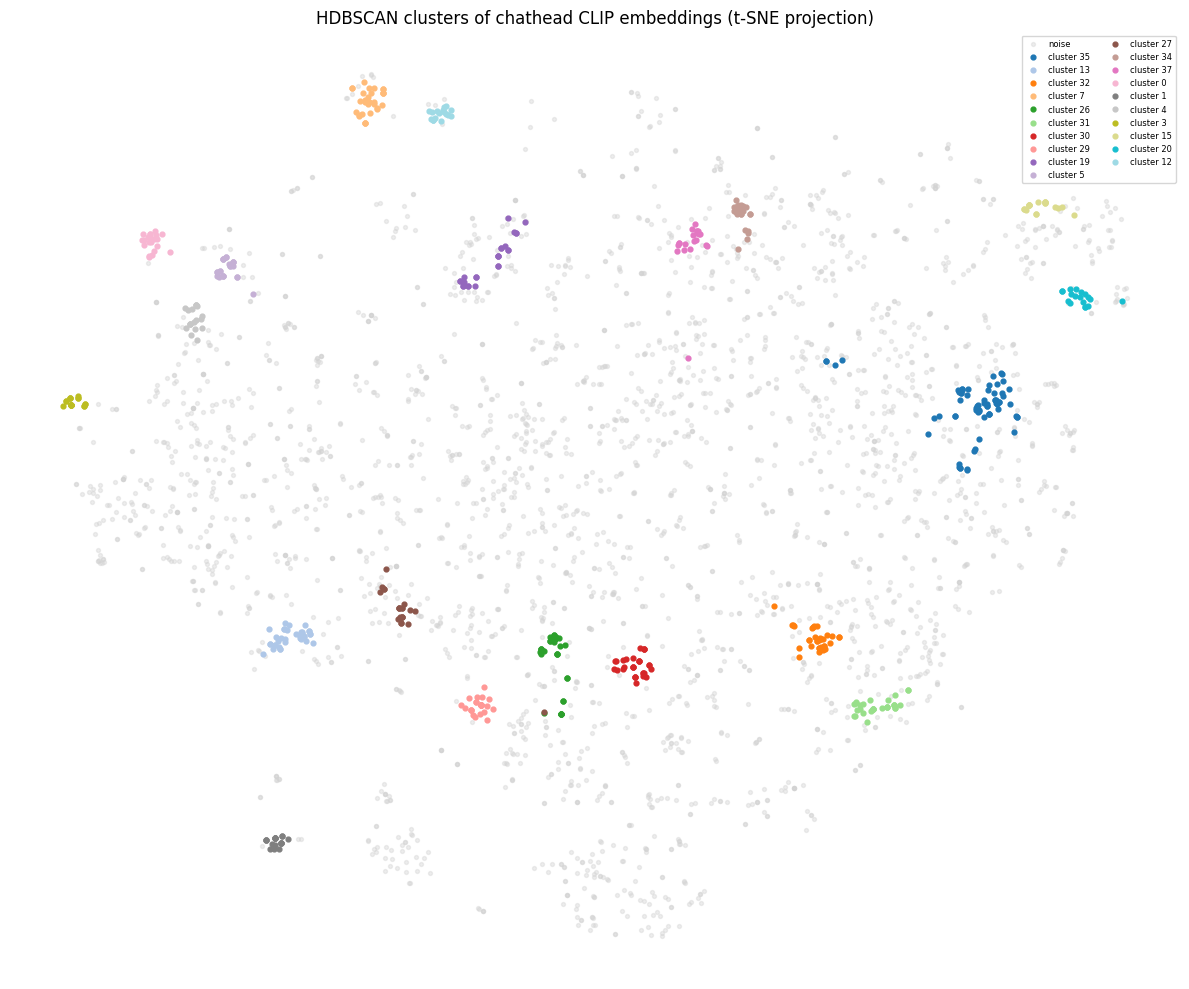

In [45]:
# Visualize HDBSCAN clusters
from sklearn.manifold import TSNE

tsne = TSNE(n_components=2, random_state=42, perplexity=30)
embedded_2d = tsne.fit_transform(norm_emb)

fig, ax = plt.subplots(figsize=(12, 10))
noise_mask = cluster_labels == -1
ax.scatter(embedded_2d[noise_mask, 0], embedded_2d[noise_mask, 1], color="lightgray", s=8, alpha=0.4, label="noise")

top_clusters_for_color = cluster_sizes.head(20).index
cmap = plt.cm.tab20(np.linspace(0, 1, 20))
for i, c in enumerate(top_clusters_for_color):
    mask = cluster_labels == c
    ax.scatter(embedded_2d[mask, 0], embedded_2d[mask, 1], color=cmap[i], s=12, label=f"cluster {c}")

ax.set_title("HDBSCAN clusters of chathead CLIP embeddings (t-SNE projection)")
ax.axis("off")
ax.legend(fontsize=6, ncol=2, loc="upper right")
plt.tight_layout()
plt.savefig("../img/chathead_hdbscan_clusters_tsne.png")
plt.show()

In [46]:
# Validate clusters against metadata
merged = cluster_df.merge(npc, on="id", how="left")
top_clusters = cluster_sizes.head(10).index

for c in top_clusters:
    sub = merged[merged["cluster"] == c]
    top_class = sub["Class"].value_counts().head(3)
    print(f"Cluster {c} (n={len(sub)}): {dict(top_class)}")

Cluster 35 (n=68): {'Human': np.int64(66), 'Werewolf': np.int64(1)}
Cluster 13 (n=36): {'Gnome': np.int64(36)}
Cluster 32 (n=33): {'Human': np.int64(33)}
Cluster 7 (n=32): {'Dorgeshuun': np.int64(32)}
Cluster 26 (n=31): {'Human': np.int64(29), 'Dwarf': np.int64(2)}
Cluster 31 (n=31): {'Human': np.int64(31)}
Cluster 30 (n=31): {'Dwarf': np.int64(30), 'Dwarf ( Imcando-descendant )': np.int64(1)}
Cluster 29 (n=27): {'Dwarf': np.int64(25), 'Dwarf ( Imcando-descendant )': np.int64(2)}
Cluster 19 (n=26): {'Human': np.int64(26)}
Cluster 5 (n=24): {'Vampyre': np.int64(24)}


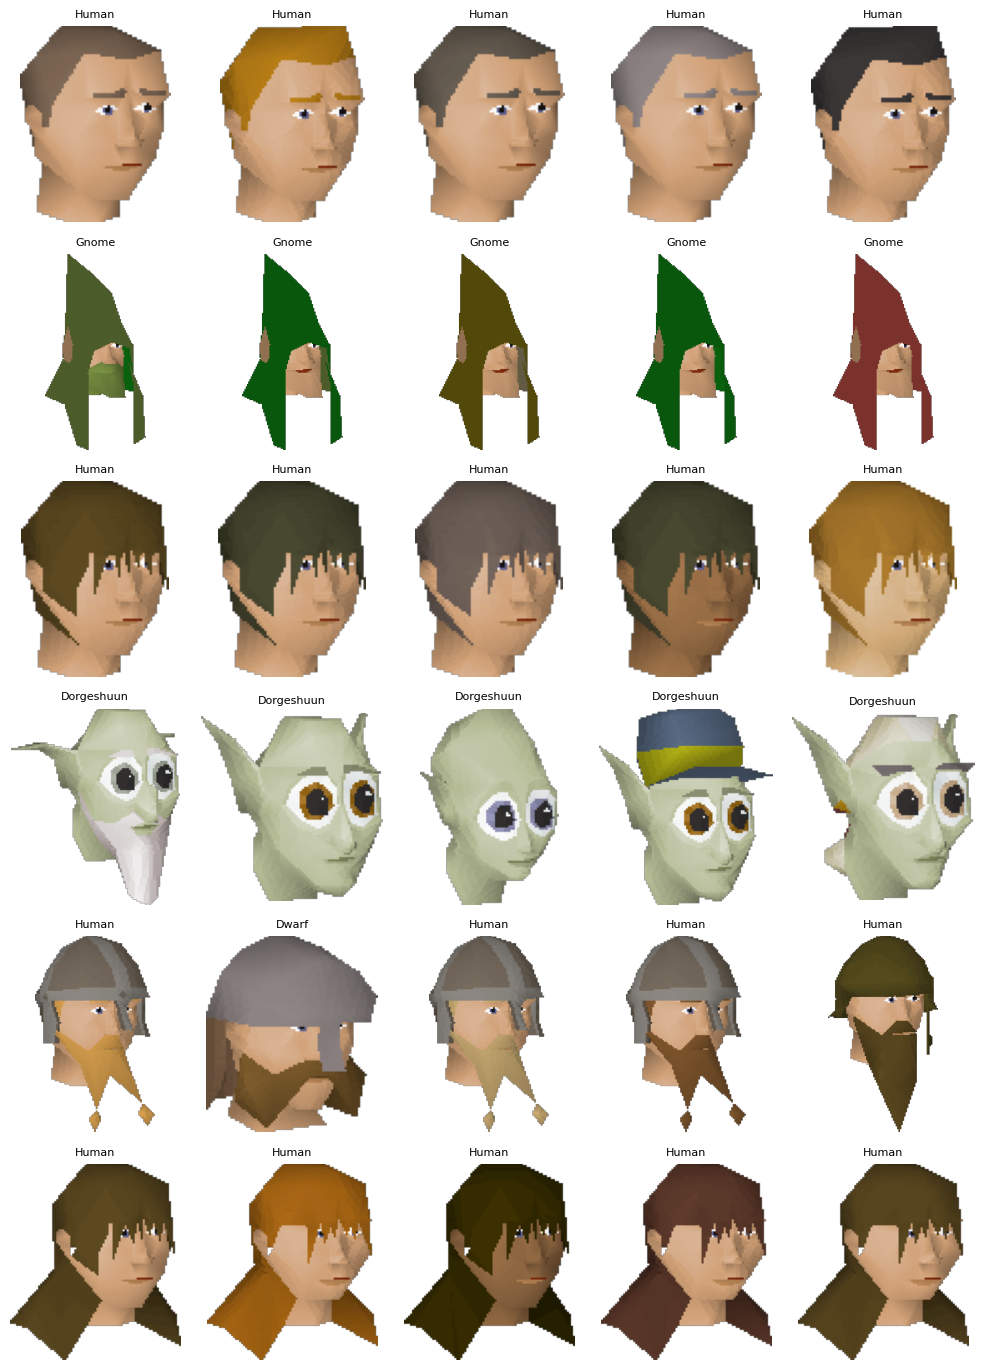

In [47]:
# Visual sanity check on largest clusters identified
fig, axes = plt.subplots(len(top_clusters[:6]), 5, figsize=(10, len(top_clusters[:6]) * 2.3))
for row, c in enumerate(top_clusters[:6]):
    sub = merged[merged["cluster"] == c]
    sample = sub.sample(min(5, len(sub)), random_state=1)
    for col, (_, r) in enumerate(sample.iterrows()):
        img = Image.open(f"../data/chatheads/{r['id']}.png")
        axes[row, col].imshow(img)
        axes[row, col].set_title(r["Class"], fontsize=8)
        axes[row, col].axis("off")
    axes[row, 0].set_ylabel(f"cluster {c}", fontsize=9, rotation=0, labelpad=35)
plt.tight_layout()
plt.savefig("../img/chathead_cluster_samples.png")
plt.show()

> Based on these sample of images from the clusters generated, it seems apparent that it is clustering based on class and some obvious features like gender or similar facial features like hairstyles or facial hair. We need to come up with a way to sample some of these images in a way that represents the "possibilities" within a certain class (e.g. female human with long and brown hair and light skin vs female human with long black hair and dark skin or Dorgeshuun with blue eyes and no facial hair vs Dorgeshuun with brown eyes and a beard) to capture the "feature diversity" within a certain class/cluster (kind of like a cluster within a cluster)--which we will use to train the model.
>
> Think like: we want to teach the model that "these images represent what a female character can look like, regardless of class" or "these images represent the possibilities for dwarves" etc. 

In [48]:
dup_check = dup_df.merge(cluster_df, left_on="id_a", right_on="id").rename(columns={"cluster": "cluster_a"}).drop(columns="id")
dup_check = dup_check.merge(cluster_df, left_on="id_b", right_on="id").rename(columns={"cluster": "cluster_b"}).drop(columns="id")

same_cluster_rate = (dup_check["cluster_a"] == dup_check["cluster_b"]).mean()
print(f"{same_cluster_rate:.1%} of near-duplicate pairs fall in the same HDBSCAN cluster")

# flag the exceptions -- worth eyeballing these specifically
mismatches = dup_check[dup_check["cluster_a"] != dup_check["cluster_b"]]
print(f"{len(mismatches)} near-dup pairs span two different HDBSCAN clusters")
mismatches[["id_a", "id_b", "similarity", "Name_a", "Name_b", "cluster_a", "cluster_b"]].head(10)

79.5% of near-duplicate pairs fall in the same HDBSCAN cluster
1925 near-dup pairs span two different HDBSCAN clusters


,id_a,id_b,similarity,Name_a,Name_b,cluster_a,cluster_b
81,3437,3438,1.000000,Sassilik,Sassilik,19,-1
455,2535,3146,1.000000,Major Collect,Private Pierreb,27,26
1356,1949,2863,0.997754,Hetty,Nora T. Hagg,11,-1
1385,1000,3429,0.997568,Disappointed mother,Sarah,-1,36
1405,4350,4351,0.997459,Wounded soldier,Wounded soldier,-1,34
1459,1874,2378,0.997174,Hambling,Lenny,-1,35
1537,1139,1534,0.996797,Edmond,Gabooty,-1,27
1606,1768,4060,0.996682,Guard,Treznor,-1,21
1607,3726,4060,0.996682,Soldier,Treznor,-1,21
1647,1000,2051,0.996557,Disappointed mother,Information clerk,-1,36


### Handling potentially problematic images (near-dupes, low-res images)

In [49]:
# Group near-duplicates into clusters and pick one representative each
import networkx as nx

G = nx.Graph()
G.add_edges_from(zip(dup_df["id_a"], dup_df["id_b"]))
dup_clusters = list(nx.connected_components(G))
print(f"{len(dup_clusters)} near-duplicate clusters found")

ids_to_drop = set()
for cluster in dup_clusters:
    cluster = list(cluster)
    ids_to_drop.update(cluster[1:])  # keep first id in each cluster, drop the rest

print(f"{len(ids_to_drop)} redundant near-duplicate images will be dropped")

381 near-duplicate clusters found
1761 redundant near-duplicate images will be dropped


In [50]:
CONF_THRESHOLD = 0.5

def finalize_caption_v2(row):
    parts = []
    if pd.notna(row["Class"]): parts.append(row["Class"])
    if pd.notna(row["Gender"]): parts.append(row["Gender"])
    if row["facial_hair"] != "clean_shaven" and row["facial_hair_conf"] >= CONF_THRESHOLD:
        parts.append(f"a {row['facial_hair']}")
    if row["hair_color_conf"] >= CONF_THRESHOLD:
        parts.append(f"{row['hair_color']} hair")
    if row["headwear_conf"] >= CONF_THRESHOLD and row["headwear"] != "none":
        parts.append(row["headwear"])
    if row["eyewear_conf"] >= CONF_THRESHOLD and row["eyewear"] != "none":
        parts.append(row["eyewear"])
    base = ", ".join(parts) if parts else "an OSRS character"
    if pd.notna(row["Location"]):
        base += f", found in {row['Location']}"
    return base

attrs_full = pd.read_csv("../data/npc_attributes.csv").merge(
    pd.read_csv("../data/npc.csv")[["id", "Location"]], on="id", how="left"
)
attrs_full["final_caption_v2"] = attrs_full.apply(finalize_caption_v2, axis=1)

In [51]:
# sanity check
attrs_full[["id", "final_caption_v2"]].sample(5)

,id,final_caption_v2
2019,2019,"Dwarf, Female, a beard, bald hair, found in Mi..."
2422,2422,"Lizard, found in Prifddinas"
1517,1517,"an OSRS character, found in Tombs of Amascut"
411,411,"Human, Female, hat, glasses_or_goggles, found ..."
2277,2277,"Human, Male, glasses_or_goggles, found in Varr..."


In [52]:
# Build the actual final, trimmed training manifest (combines both fixes)
chathead_manifest_final = chathead_manifest[~chathead_manifest["id"].isin(ids_to_drop)].copy()
chathead_manifest_final = chathead_manifest_final.merge(
    attrs_full[["id", "final_caption_v2"]], on="id", how="left"
)
chathead_manifest_final = chathead_manifest_final.rename(columns={"final_caption_v2": "final_caption_clean"})

print(f"{len(chathead_manifest)} -> {len(chathead_manifest_final)} after dedup")
chathead_manifest_final[["id", "final_caption_clean"]].sample(5)

3473 -> 1712 after dedup


,id,final_caption_clean
980,2528,"Human, Male, a beard, glasses_or_goggles, foun..."
1503,3849,"Human, Male, bald hair, glasses_or_goggles, fo..."
1062,2730,"Monkey , Cow, bald hair, found in Field south ..."
616,1646,"Elf, Male, glasses_or_goggles, found in Prifdd..."
150,336,"Human, Male, bald hair, glasses_or_goggles, fo..."


0


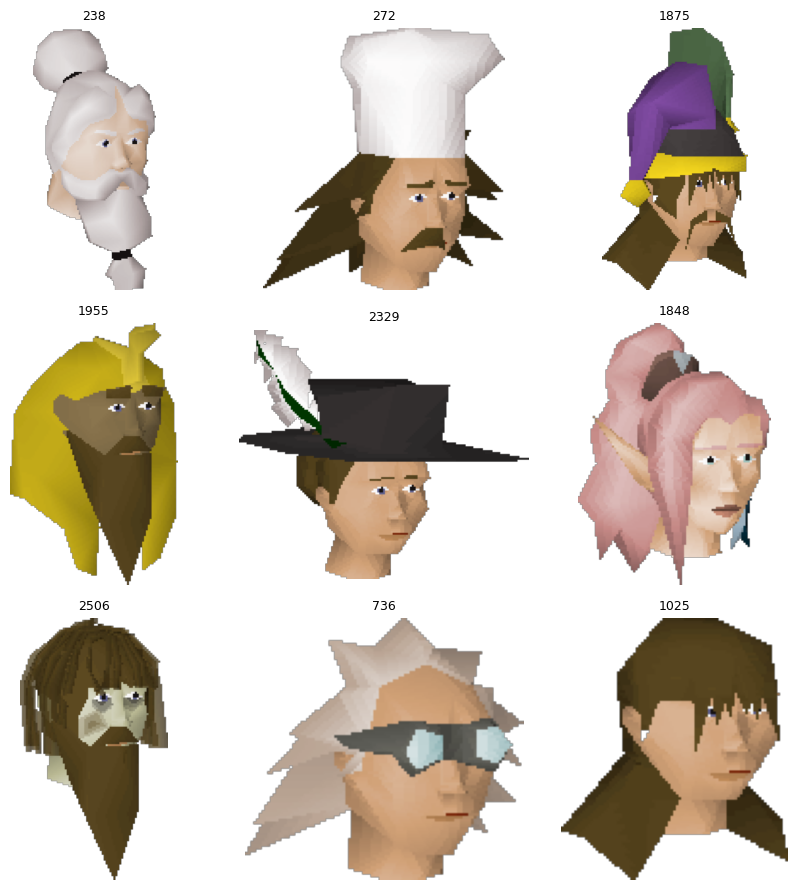

In [53]:
# final sanity on manifest:
# any missing captions?
print(chathead_manifest_final["final_caption_clean"].isna().sum())

# quick visual spot-check that diversity wasn't accidentally over-trimmed
sample_ids = chathead_manifest_final["id"].sample(9, random_state=1).tolist()
fig, axes = plt.subplots(3, 3, figsize=(9, 9))
for ax, npc_id in zip(axes.flat, sample_ids):
    img = Image.open(f"../data/chatheads/{npc_id}.png")
    ax.imshow(img); ax.set_title(str(npc_id), fontsize=9); ax.axis("off")
plt.tight_layout()
plt.show()

> This confirms the dedup step worked as intended--it trimmed the redundant copies (like the "Banker" reused across locations) while preserving genuine visual diversity across the remaining 1,712 images.

1 images in the final manifest fall below the 30px floor


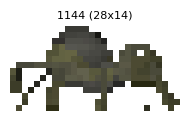

In [54]:
# Next handle low-res images like id 1129 whose ears were cut off
low_res_check = chathead_manifest_final.merge(chathead_dims_id, on="id", how="left")
below_floor = low_res_check[low_res_check["max_dim"] < 30] # set arbitrary cutoff dimension (in px/pixels) that seems reasonable for LoRA training
print(f"{len(below_floor)} images in the final manifest fall below the 30px floor")

# visualize them to judge how bad the cutoff actually is
fig, axes = plt.subplots(1, min(len(below_floor), 9), figsize=(len(below_floor)*2, 2))
for ax, (_, row) in zip(axes if len(below_floor) > 1 else [axes], below_floor.iterrows()):
    img = Image.open(f"../data/chatheads/{row['id']}.png")
    ax.imshow(img); ax.set_title(f"{row['id']} ({row['width']}x{row['height']})", fontsize=8); ax.axis("off")
plt.tight_layout()
plt.show()

In [55]:
# check how CLIP analyzes id 1129's attributes/features to see if it's worth learning from it
import torch
from PIL import Image
from transformers import CLIPProcessor, CLIPModel

device = "cuda" if torch.cuda.is_available() else "cpu"
clip_model = CLIPModel.from_pretrained("openai/clip-vit-base-patch32").to(device)
clip_processor = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")

img = Image.open("../data/chatheads/1129.png").convert("RGB")

prompts = [
    "a character with visible, intact ears",
    "a character with ears cut off or missing from the image",
    "a rabbit with long ears",
    "a duck with a beak",
    "a character with no visible ears"
]

inputs = clip_processor(text=prompts, images=img, return_tensors="pt", padding=True).to(device)
with torch.no_grad():
    outputs = clip_model(**inputs)
    probs = outputs.logits_per_image.softmax(dim=1).squeeze().cpu().tolist()

for prompt, prob in sorted(zip(prompts, probs), key=lambda x: -x[1]):
    print(f"{prob:.3f}  {prompt}")

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

0.396  a rabbit with long ears
0.313  a character with ears cut off or missing from the image
0.247  a character with visible, intact ears
0.043  a character with no visible ears
0.001  a duck with a beak


> It looks like CLIP successfully captured `id 1129`'s bunny ears even if they were cut off from the original image. We should be good to include this and move on with the image preprocessing step. 

## Chatheads Image Preprocessing

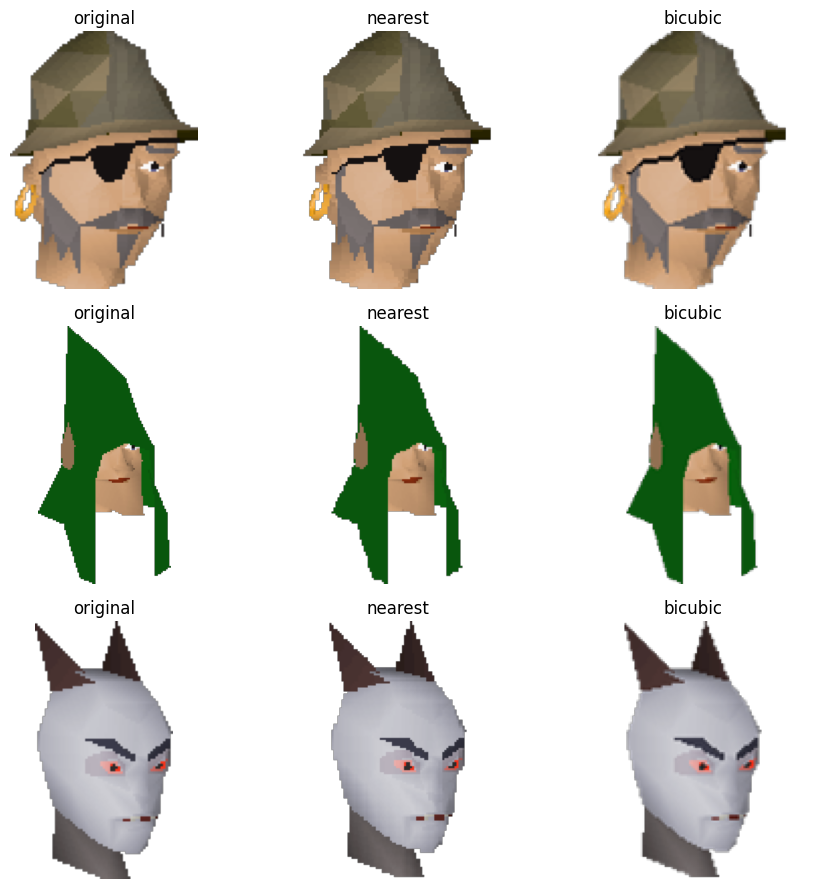

In [56]:
MIN_DIM = 30
TARGET_SIZE = 128

def resize_and_pad(img, target_size=TARGET_SIZE, resample=Image.NEAREST):
    img = img.convert("RGBA")
    w, h = img.size
    scale = target_size / max(w, h)
    new_w, new_h = int(w * scale), int(h * scale)
    resized = img.resize((new_w, new_h), resample)

    canvas = Image.new("RGBA", (target_size, target_size), (0, 0, 0, 0))
    paste_x = (target_size - new_w) // 2
    paste_y = (target_size - new_h) // 2
    canvas.paste(resized, (paste_x, paste_y), resized)
    return canvas

# quick visual test: nearest vs bicubic, on a few samples
fig, axes = plt.subplots(3, 3, figsize=(9, 9))
sample_ids = chathead_manifest["id"].sample(3, random_state=1).tolist()
for row, npc_id in enumerate(sample_ids):
    img = Image.open(f"../data/chatheads/{npc_id}.png")
    axes[row, 0].imshow(img); axes[row, 0].set_title("original")
    axes[row, 1].imshow(resize_and_pad(img, resample=Image.NEAREST)); axes[row, 1].set_title("nearest")
    axes[row, 2].imshow(resize_and_pad(img, resample=Image.BICUBIC)); axes[row, 2].set_title("bicubic")
    for ax in axes[row]: ax.axis("off")
plt.tight_layout()
plt.show()

> Based on the results, above **bicubic** looks the smoothest but nearest-neighbor looks truer to the OG OSRS art style. I'll experiment with nearest-neighbor first and see what the image generation output looks like.

### Using Nearest-Neighbor

In [57]:
import os
from PIL import Image

OUTPUT_DIR = "../data/chatheads_processed"
os.makedirs(OUTPUT_DIR, exist_ok=True)

processed_count, failed = 0, []
for _, row in chathead_manifest_final.iterrows():
    try:
        img = Image.open(f"../data/chatheads/{row['id']}.png")
        processed = resize_and_pad(img, target_size=TARGET_SIZE, resample=Image.NEAREST)
        processed.save(f"{OUTPUT_DIR}/{row['id']}.png")
        processed_count += 1
    except Exception as e:
        failed.append((row["id"], str(e)))

print(f"Processed {processed_count} images, {len(failed)} failed")
if failed:
    print(failed[:10])

Processed 1712 images, 0 failed


In [58]:
# examine the images that failed to process, if any
if failed:
    fig, axes = plt.subplots(1, len(failed), figsize=(len(failed)*2, 2))
    for ax, (npc_id, error) in zip(axes if len(failed) > 1 else [axes], failed):
        try:
            img = Image.open(f"../data/chatheads/{npc_id}.png")
            ax.imshow(img); ax.set_title(f"{npc_id}\n{error}", fontsize=8)
        except Exception as e:
            ax.text(0.5, 0.5, f"Failed to load\n{npc_id}\n{error}", ha='center', va='center', fontsize=8)
        ax.axis("off")
    plt.tight_layout()
    plt.show()

In [59]:
# sanity check: confirm if every processed image is the target size (128x128)
sizes_check = {Image.open(f"{OUTPUT_DIR}/{f}").size for f in os.listdir(OUTPUT_DIR)}
print(sizes_check)  # should be exactly (128, 128)

{(128, 128)}


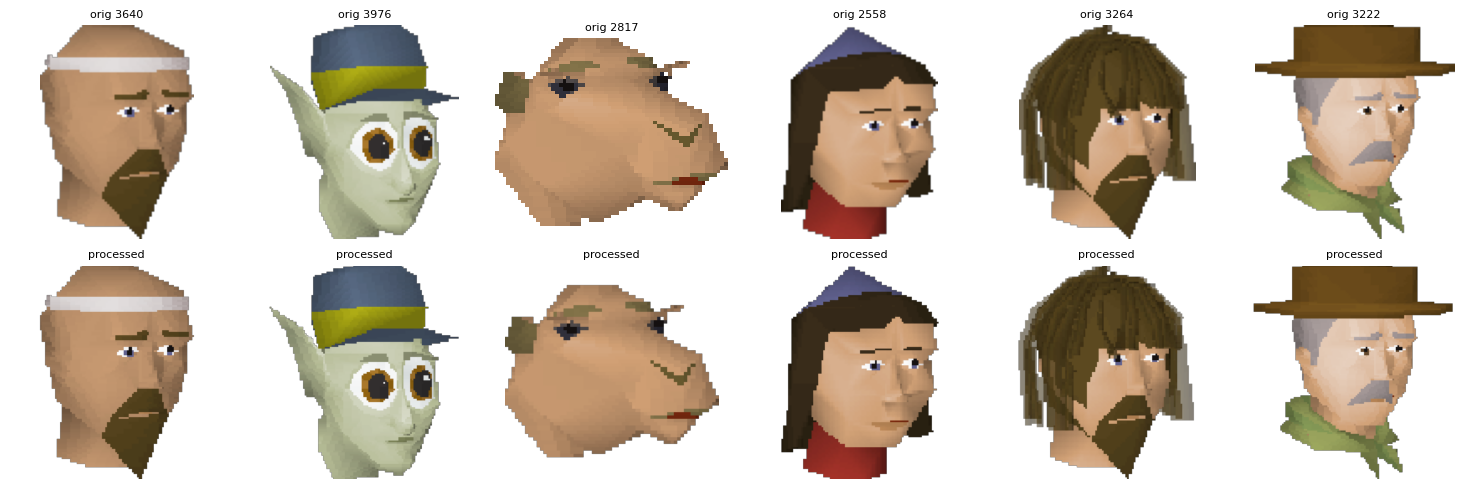

In [60]:
# visual sanity checl: original vs processed for a few samples
sample_ids = chathead_manifest_final["id"].sample(6, random_state=2).tolist()
fig, axes = plt.subplots(2, 6, figsize=(15, 5))
for col, npc_id in enumerate(sample_ids):
    orig = Image.open(f"../data/chatheads/{npc_id}.png")
    proc = Image.open(f"{OUTPUT_DIR}/{npc_id}.png")
    axes[0, col].imshow(orig); axes[0, col].set_title(f"orig {npc_id}", fontsize=8); axes[0, col].axis("off")
    axes[1, col].imshow(proc); axes[1, col].set_title("processed", fontsize=8); axes[1, col].axis("off")
plt.tight_layout()
plt.savefig("../img/chathead_preprocessing_check.png")
plt.show()

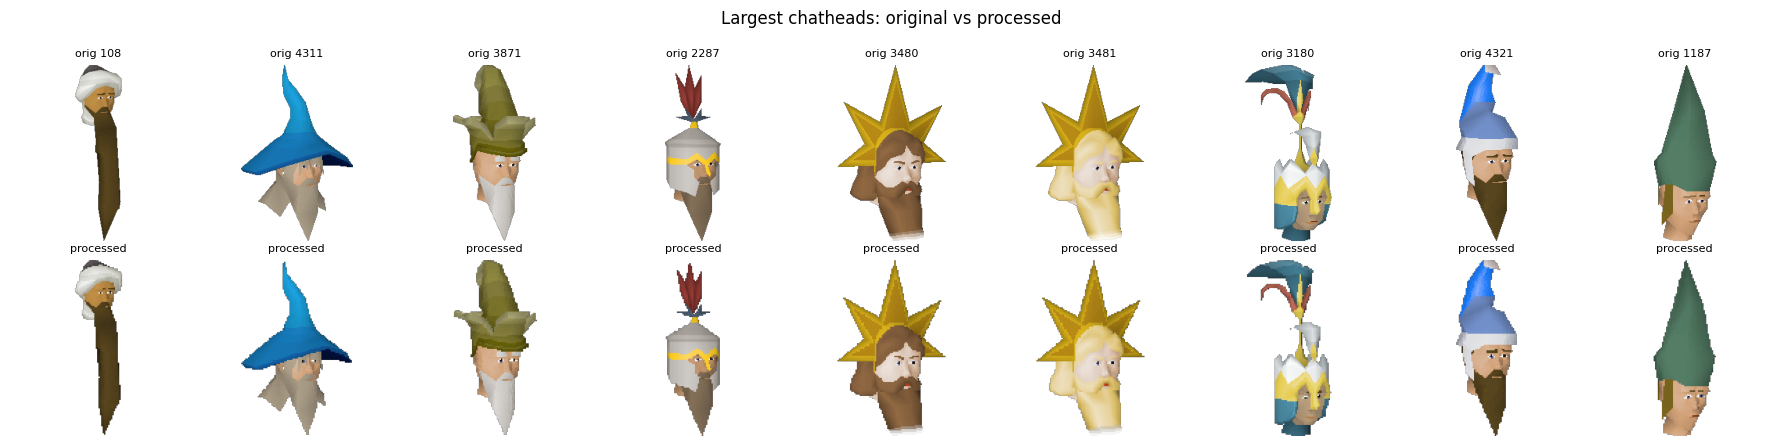

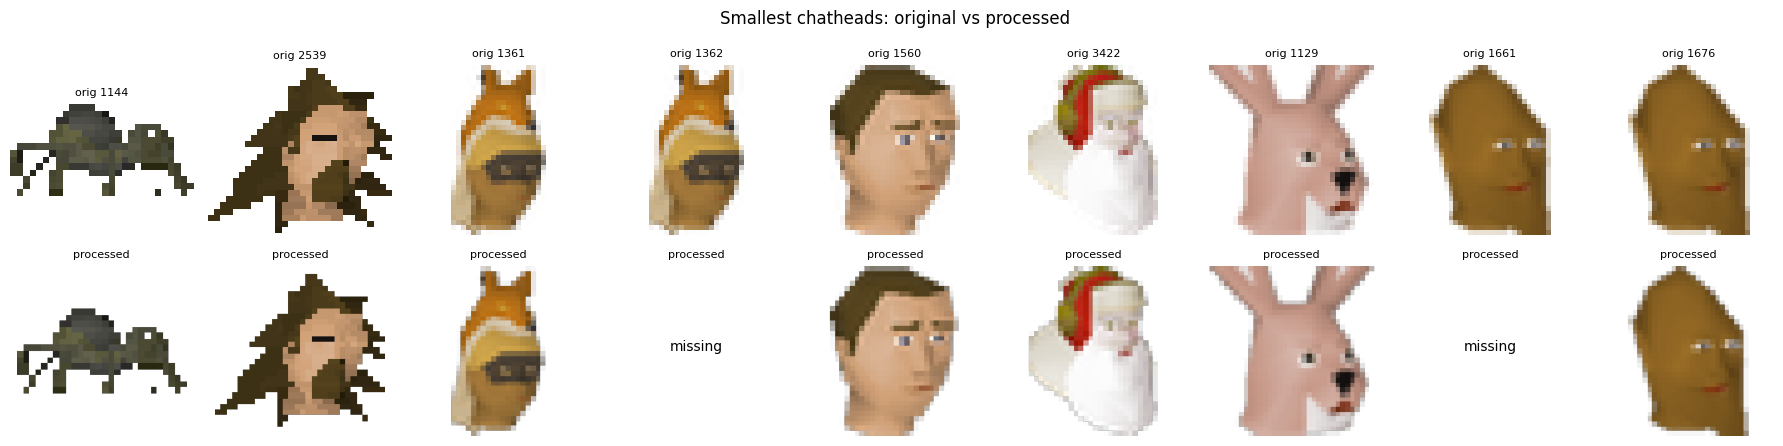

In [61]:
# sanity check small and large chatheads after processing
n = 9
largest_check = chathead_dims_id.nlargest(n, "max_dim")["id"].tolist()
smallest_check = chathead_dims_id.nsmallest(n, "max_dim")["id"].tolist()

def plot_orig_vs_processed(ids, title):
    fig, axes = plt.subplots(2, len(ids), figsize=(len(ids)*2, 4.5))
    for col, npc_id in enumerate(ids):
        orig_path = f"../data/chatheads/{npc_id}.png"
        proc_path = f"../data/chatheads_processed/{npc_id}.png"
        orig = Image.open(orig_path)
        axes[0, col].imshow(orig)
        axes[0, col].set_title(f"orig {npc_id}", fontsize=8)
        axes[0, col].axis("off")
        if os.path.exists(proc_path):
            proc = Image.open(proc_path)
            axes[1, col].imshow(proc)
        else:
            axes[1, col].text(0.5, 0.5, "missing", ha="center")
        axes[1, col].set_title("processed", fontsize=8)
        axes[1, col].axis("off")
    plt.suptitle(title)
    plt.tight_layout()
    plt.show()

plot_orig_vs_processed(largest_check, "Largest chatheads: original vs processed")
plot_orig_vs_processed(smallest_check, "Smallest chatheads: original vs processed")

> Looks like some images from small chatheads were not properly processed so let's pull up a list of images in the data that might have the same results

In [62]:
processed_ids = {int(f.split(".")[0]) for f in os.listdir("../data/chatheads_processed")}
manifest_ids = set(chathead_manifest_final["id"])

missing_ids = manifest_ids - processed_ids
print(f"{len(missing_ids)} images are missing a processed version")
print(sorted(missing_ids)[:30])

missing_df = chathead_manifest_final[chathead_manifest_final["id"].isin(missing_ids)]
missing_df.to_csv("../data/missing_processed_chatheads.csv", index=False)
missing_df

0 images are missing a processed version
[]


,id,Name,Class,Gender,facial_hair,facial_hair_conf,hair_color,hair_color_conf,headwear,headwear_conf,...,cape_conf,wings,wings_conf,body_build,body_build_conf,caption,Location,final_caption,image_path,final_caption_clean


> Since the missing chatheads don't appear in the list above^^, it means these specific chatheads were dropped during the deduplication step.

## Appendix
> Extra info on my pipeline and workflow, for reference.

Pipeline Components Explained
1. VAE (Variational Autoencoder)
> Simple Explanation: An image compression tool, like a zip file for pixels.Functional Role: Standard $512 \times 512$ or $128 \times 128$ pixel images have too many dimensions for a GPU to denoise efficiently. The VAE Encoder compresses pixel space into a smaller "latent space" representation (reducing spatial dimensions by a factor of 8). The U-Net does all its work in this small latent space. Once denoising is finished, the VAE Decoder unpacks those latents back into visible RGB pixels.
2. CLIP Text Encoder
> Simple Explanation: A translator converting human words into spatial concepts.Functional Role: CLIP takes your text caption (e.g., "an OSRS wizard with a dark robe") and turns it into a mathematical vector representation. It doesn't generate images; it provides spatial "guidance instructions" to the U-Net so the output matches the text.
3. U-Net Denoiser
> Simple Explanation: The actual artist removing static to reveal an image.Functional Role: This is the core neural network. It takes a noisy latent vector, receives text vectors from CLIP via cross-attention, and predicts how much noise to subtract to get closer to a coherent latent image. This is what you fine-tune.

**Key Hyperparameters for Fine-Tuning & Troubleshooting**
> When troubleshooting bad outputs during LoRA fine-tuning, these are the primary parameters you adjust:

| Hyperparameter | What It Controls | Troubleshooting |
|----------------|------------------|-----------------|
|Impact LoRA Rank ($r$) | Dimensionality of the LoRA matrices ($A \cdot B$).| **Too Low** ($r=2\text{--}4$): Output looks generic; fails to capture fine OSRS features. <br> **Too High** ($r=32\text{--}64$): Overfits quickly, wastes VRAM, and can cause training instability.
|LoRA Alpha ($\alpha$) | Scaling factor applied to LoRA updates. | Acts as weight strength. Higher values force the model to prioritize the LoRA adapter over the base Stable Diffusion model. Standard practice: set $\alpha = r$ or $\alpha = 2r$.
|Learning Rate ($lr$)| Speed of weight adjustments (typically $10^{-4}$ to $10^{-5}$). | **Too High** ($>10^{-3}$): Output breaks into random color noise/artifacts. <br> **Too Low** ($<10^{-6}$): Model barely changes; output looks like default SD 1.5.
|Training Steps / Epochs | How long the model trains on the dataset. | **Underfitted**: Character shapes are smooth photorealistic humans instead of OSRS low-poly style.<br> **Overfitted**: Generates exact duplicates of training images, ignoring prompt text.
|Resolution | Target dimension fed to VAE ($128 \times 128$). | Mismatches between preprocessed padding and target dimensions cause severe stretching or blurriness.

Notes for Camille:

> Git bash commands to use when starting up again:
> - git status (make sure result is your work in your branch. In this case, it should be a path ending in `camille/lora-feasibility` and working in `06_lora_feasibility.ipynb`)
>
> Git bash commands for when you're done and want to push any changes:
> - git add <changed files>
> - git commit -m "<short message describing the change>"
> - git push